In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [7]:
df = pd.read_csv('D:\ML project\DATASETS ML\predictive_maintenance.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [8]:
df.shape

(10000, 10)

In [9]:
df.drop(['Product ID', 'UDI'], axis=1, inplace=True)
df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [10]:
df['Target'].value_counts()


0    9661
1     339
Name: Target, dtype: int64

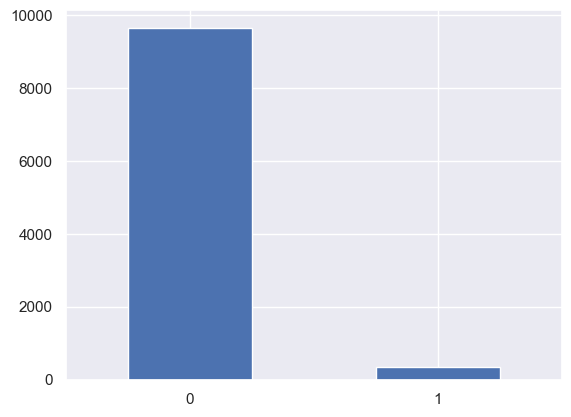

In [11]:
df['Target'].value_counts().plot.bar(rot=0)
plt.show()

In [12]:
df['Failure Type'].value_counts()

No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: Failure Type, dtype: int64

In [13]:
df['Failure Type'].replace(to_replace=['No Failure', 'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure', 'Tool Wear Failure', 'Random Failures'],
value=['NoF', 'HDF', 'PF', 'OF', 'TWF', 'RF'], inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,NoF
1,L,298.2,308.7,1408,46.3,3,0,NoF
2,L,298.1,308.5,1498,49.4,5,0,NoF
3,L,298.2,308.6,1433,39.5,7,0,NoF
4,L,298.2,308.7,1408,40.0,9,0,NoF


TypeError: countplot() got multiple values for argument 'data'

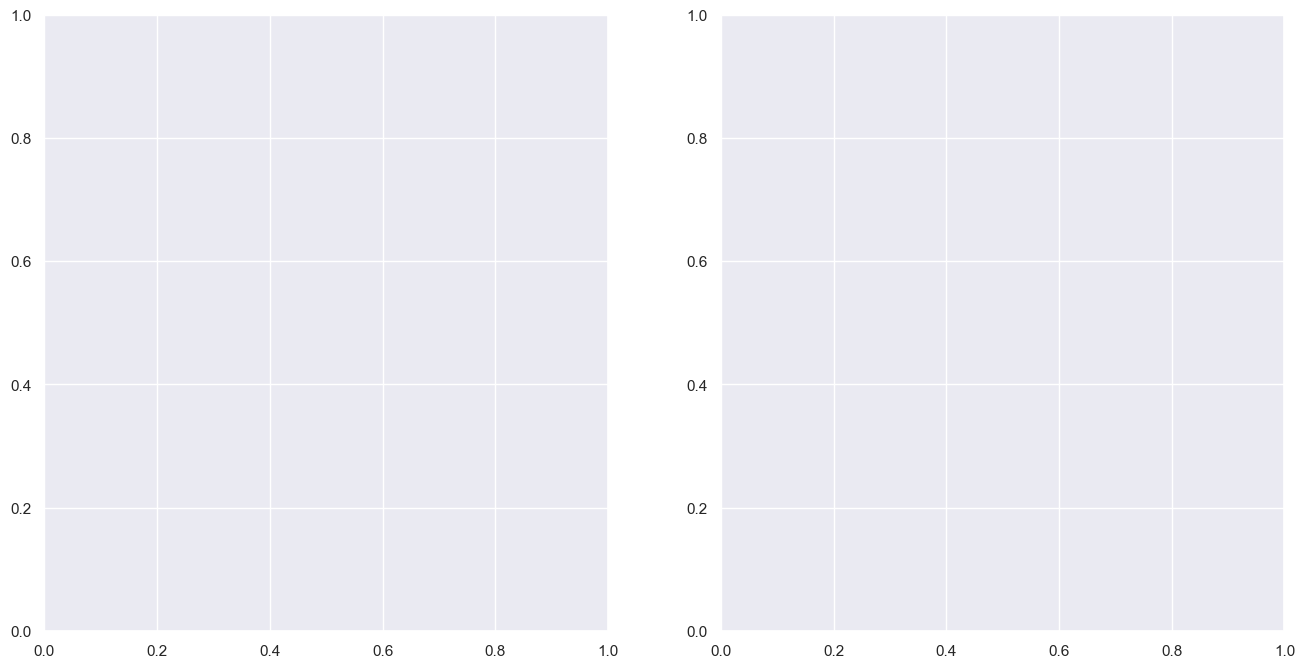

In [14]:
fig, ax = plt.subplots(1,2 , figsize=(16, 8))

sns.countplot("Type", hue="Target",data=df, ax=ax[0])
sns.countplot("Failure Type", hue="Target",data=df, ax=ax[1])

plt.show()

In [15]:
df = pd.get_dummies(df)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_H,Type_L,Type_M,Failure Type_HDF,Failure Type_NoF,Failure Type_OF,Failure Type_PF,Failure Type_RF,Failure Type_TWF
0,298.1,308.6,1551,42.8,0,0,0,0,1,0,1,0,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,1,0,0,1,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,1,0,0,1,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,1,0,0,1,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,1,0,0,1,0,0,0,0


In [16]:
df.drop('Failure Type_NoF', axis=1, inplace=True)
tempt = df.pop('Target')
df = pd.concat([df, tempt], 1)
df.head()

C:\Users\AMITH\AppData\Local\Temp\ipykernel_6756\2923382133.py:3: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  df = pd.concat([df, tempt], 1)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M,Failure Type_HDF,Failure Type_OF,Failure Type_PF,Failure Type_RF,Failure Type_TWF,Target
0,298.1,308.6,1551,42.8,0,0,0,1,0,0,0,0,0,0
1,298.2,308.7,1408,46.3,3,0,1,0,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,1,0,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,1,0,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,1,0,0,0,0,0,0,0


In [17]:
df.shape

(10000, 14)

In [18]:
X_cols = ['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]',
          'Torque [Nm]', 'Tool wear [min]','Type_H','Type_L', 'Type_M']

y_cols = ['Failure Type_OF', 'Failure Type_PF', 'Failure Type_PF', 'Failure Type_TWF', 'Target' ]

X = df[X_cols]
y = df[y_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=True, random_state=42)

In [19]:
model = RandomForestClassifier(random_state=42)


# Cross Validation and Grid Search
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': ['auto', 'log2'],
    'max_depth' : [ 8, 11, 13, 15, 17],
    'criterion' :['gini', 'entropy']
}

CV_model = GridSearchCV(estimator=model, param_grid=param_grid, cv= 5)
CV_model.fit(X_train, y_train)

C:\Users\AMITH\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
200 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\AMITH\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\AMITH\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\AMITH\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\AMITH\anaconda3\Lib\site-packag

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [8, 11, 13, 15, 17],
                         'max_features': ['auto', 'log2'],
                         'n_estimators': [50, 100, 200, 500]})

In [20]:
param = CV_model.best_params_
param
     

{'criterion': 'entropy',
 'max_depth': 13,
 'max_features': 'log2',
 'n_estimators': 200}

In [21]:
mdl = RandomForestClassifier(max_depth= param['max_depth'],
                             max_features=param['max_features'],
                             n_estimators=param['n_estimators'],
                             criterion=param['criterion'],
                             random_state=42)

In [22]:
mdl.fit(X_train, y_train)
y_pred = mdl.predict(X_test)

In [23]:
accuracy_score(y_test, y_pred)

0.9827272727272728

In [1]:
!pip install pandas


In [2]:
import pandas as pd

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split

# Load the dataset
df = pd.read_csv("D:/ML project/DATASETS ML/predictive_maintenance.csv")

# Preprocess the dataset
df['UDI'], _ = pd.factorize(df['UDI'])
df['Product ID'], _ = pd.factorize(df['Product ID'])
df['Type'], _ = pd.factorize(df['Type'])
df['Air temperature [K]'], _ = pd.factorize(df['Air temperature [K]'])
df['Process temperature [K]'], _ = pd.factorize(df['Process temperature [K]'])
df['Rotational speed [rpm]'], _ = pd.factorize(df['Rotational speed [rpm]'])
df['Torque [Nm]'], _ = pd.factorize(df['Torque [Nm]'])
df['Tool wear [min]'], _ = pd.factorize(df['Tool wear [min]'])
df['Target'], _ = pd.factorize(df['Target'])
df['Failure Type'], _ = pd.factorize(df['Failure Type'])

# Define features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit the RandomForestClassifier model
model = RandomForestClassifier(random_state=123)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Create a DataFrame with the results
results = pd.DataFrame({
    'Vehicle_ID': X_test['UDI'],
    'Actual': y_test,
    'RandomForest_Prediction': y_pred
})

# Define a function to decide if a vehicle needs maintenance based on the prediction
def needs_maintenance(prediction):
    # Simple rule: Assume prediction 0 means no maintenance, prediction 1 means maintenance
    return 1 if prediction == 1 else 0

results['Service_Needed'] = results['RandomForest_Prediction'].apply(needs_maintenance)

# Print the results with the maintenance decision
print(results.head())  # Print only the first few rows for brevity

# Print detailed maintenance decision for each vehicle
for index, row in results.iterrows():
    service_needed = 'needs service' if row['Service_Needed'] == 1 else 'does not need service'
    print(f"Vehicle ID {row['Vehicle_ID']} {service_needed}")

# Calculate and print the evaluation metrics
print("Maintenance Prediction Accuracy: ", accuracy_score(y_test, results['Service_Needed']))
print("F1 Score: ", f1_score(y_test, results['Service_Needed']))
print("Confusion Matrix: \n", confusion_matrix(y_test, results['Service_Needed']))
print("ROC AUC Score: ", roc_auc_score(y_test, results['Service_Needed']))


      Vehicle_ID  Actual  RandomForest_Prediction  Service_Needed
2656        2656       0                        0               0
445          445       0                        0               0
9505        9505       0                        0               0
332          332       0                        0               0
4168        4168       0                        0               0
Vehicle ID 2656 does not need service
Vehicle ID 445 does not need service
Vehicle ID 9505 does not need service
Vehicle ID 332 does not need service
Vehicle ID 4168 does not need service
Vehicle ID 2364 does not need service
Vehicle ID 6097 does not need service
Vehicle ID 7 does not need service
Vehicle ID 7752 does not need service
Vehicle ID 4453 does not need service
Vehicle ID 4743 does not need service
Vehicle ID 6243 does not need service
Vehicle ID 3126 does not need service
Vehicle ID 4056 does not need service
Vehicle ID 5852 does not need service
Vehicle ID 628 does not need service
Ve